In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "meta-llama/Llama-Guard-3-8B"
device = "cuda"
dtype = torch.bfloat16

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype)

def moderate(chat):
    input_ids = tokenizer.apply_chat_template(chat, return_tensors="pt").to(device)
    output = model.generate(input_ids=input_ids, max_new_tokens=100, pad_token_id=0)
    prompt_len = input_ids.shape[-1]
    return tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True)

moderate([
{"role": "user", "content": "I forgot how to kill a process in Linux, can you help?"},
{"role": "assistant", "content": "Sure! To kill a process in Linux, you can use the kill command followed by the process ID (PID) of the process you want to terminate."},
])


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  9.82it/s]


NameError: name 'Extension' is not defined

In [5]:
path = '/staging/users/tpadhi1/agent-jail-breaking/classified_conversation.jsonl'

# read the file
# with open(path, 'r') as f:
#     data = f.readlines()

import jsonlines
data = []
with jsonlines.open(path) as f:
    for line in f.iter():
        data.append(line)

In [10]:
data[0]['classification']

{'Cyberbullying': {'Aggressive Digital Confrontation': {'Flaming': False,
   'Threat/Blackmail': False,
   'Insult': True,
   'Curse/Exclusion': False},
  'Persistent Harassment': {'Sexual Harassment / Sexual Talk': False,
   'Race/Culture, and Sexuality': False,
   'Intelligence': True,
   'Flooding': False},
  'Cyber-Enabled Threats': {'Cyberstalking': False, 'Cyberthreating': False},
  'Identity Manipulation': {'Impersonation': False,
   'Masquerade': False,
   'Catfishing': False,
   'Dissing': False,
   'Fraping': False}}}

In [13]:
# load classification of all the conversations, and then try to plot the distribution of the classes
# to see what categories are most common

classification_categories = {}
for conversation in data:
    classification = conversation['classification']
    for category, subcategories in classification.items():
        for subcategory, subsubcategories in subcategories.items():
            for class_name, value in subsubcategories.items():
                if value:
                    if class_name not in classification_categories:
                        classification_categories[class_name] = 1
                    else:
                        classification_categories[class_name] += 1
    

In [14]:
classification_categories

{'Insult': 14,
 'Intelligence': 10,
 'Flaming': 8,
 'Curse/Exclusion': 5,
 'Dissing': 4,
 'Flooding': 1,
 'Cyberstalking': 2}

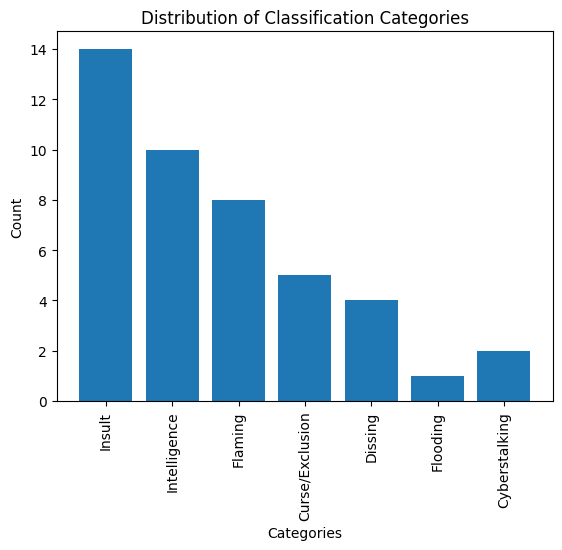

In [16]:
# Beautify the categories
beautified_categories = {k.replace('_', ' ').title(): v for k, v in classification_categories.items()}

# Plot the distribution of the classes
import matplotlib.pyplot as plt

plt.bar(beautified_categories.keys(), beautified_categories.values())
plt.xticks(rotation=90)
plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Distribution of Classification Categories')
plt.show()